In [3]:
!pip install requests pandas python-dotenv -q

import os, requests, pandas as pd
from dotenv import load_dotenv

load_dotenv()
key = os.getenv("TMDB_API_KEY")
base = "https://api.themoviedb.org/3"

# short v3 key -> query param, long v4 token (starts with eyJ) -> bearer header
hdr = {"Authorization": f"Bearer {key}"} if key and len(key) > 40 else {}
par = {} if hdr else {"api_key": key}

def get(ep, p=None):
    return requests.get(base + ep, params={**par, **(p or {})}, headers=hdr, timeout=15)

r = get("/genre/movie/list")
print("status:", r.status_code)
print(r.json()["genres"][:3])

r = get("/discover/movie", {"primary_release_year": 2015, "sort_by": "popularity.desc", "vote_count.gte": 10})
d = r.json()
print("status:", r.status_code, "| total_results:", d["total_results"], "| total_pages:", d["total_pages"])
print(list(d["results"][0].keys()))


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


status: 200
[{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}, {'id': 16, 'name': 'Animation'}]
status: 200 | total_results: 3228 | total_pages: 162
['adult', 'backdrop_path', 'genre_ids', 'id', 'title', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'release_date', 'softcore', 'video', 'vote_average', 'vote_count']


In [6]:
import random, time, json
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

random.seed(42)
ses = requests.Session()
ses.mount("https://", HTTPAdapter(max_retries=Retry(total=5, backoff_factor=1,
          status_forcelist=[429, 500, 502, 503, 504])))

cols = ["id","title","release_date","genre_ids","original_language",
        "overview","popularity","vote_average","vote_count"]
os.makedirs("data/raw", exist_ok=True)
ck = "data/raw/checkpoint.json"
done = json.load(open(ck)) if os.path.exists(ck) else {}   # {year: [rows]}

def page(y, pg):
    for _ in range(4):
        try:
            r = ses.get(base + "/discover/movie", headers=hdr, timeout=20,
                        params={**par, "primary_release_year": y, "sort_by": "popularity.desc",
                                "vote_count.gte": 10, "include_adult": "false", "page": pg})
            if r.status_code == 200:
                return r.json()
        except requests.exceptions.RequestException:
            pass
        time.sleep(3)
    return None

for y in range(2000, 2026):
    if str(y) in done:
        continue
    d = page(y, 1)
    if not d:
        print(y, "failed, rerun the cell to resume"); break
    tp = min(d["total_pages"], 500)
    yr = []
    for p in random.sample(range(1, tp + 1), min(30, tp)):
        d = page(y, p)
        if d:
            yr += [{c: m.get(c) for c in cols} for m in d["results"]]
        time.sleep(0.1)
    done[str(y)] = yr
    json.dump(done, open(ck, "w"))
    print(y, "| pages:", tp, "| rows:", len(yr))

df = pd.DataFrame([r for v in done.values() for r in v]).drop_duplicates("id")
df.to_csv("data/raw/tmdb_raw.csv", index=False)
print("saved:", df.shape)

2000 | pages: 63 | rows: 600
2001 | pages: 69 | rows: 583
2002 | pages: 72 | rows: 600
2003 | pages: 77 | rows: 600
2004 | pages: 84 | rows: 600
2005 | pages: 90 | rows: 595
2006 | pages: 99 | rows: 595
2007 | pages: 107 | rows: 600
2008 | pages: 106 | rows: 592
2009 | pages: 114 | rows: 600
2010 | pages: 118 | rows: 600
2011 | pages: 128 | rows: 600
2012 | pages: 133 | rows: 600
2013 | pages: 148 | rows: 600
2014 | pages: 153 | rows: 600
2015 | pages: 162 | rows: 600
2016 | pages: 171 | rows: 600
2017 | pages: 184 | rows: 600
2018 | pages: 184 | rows: 600
2019 | pages: 182 | rows: 590
2020 | pages: 140 | rows: 600
2021 | pages: 146 | rows: 600
2022 | pages: 158 | rows: 600
2023 | pages: 150 | rows: 600
2024 | pages: 126 | rows: 600
2025 | pages: 97 | rows: 600
saved: (15555, 9)


In [7]:
print(df.shape)
print(df.isna().sum())
print((df["overview"].fillna("").str.strip() == "").sum(), "empty overviews")
print(df["release_date"].str[:4].value_counts().sort_index().to_string())
print(df[["popularity","vote_average","vote_count"]].describe(percentiles=[.1,.5,.9,.99]))
print(df["original_language"].value_counts().head(10))

(15555, 9)
id                   0
title                0
release_date         0
genre_ids            0
original_language    0
overview             0
popularity           0
vote_average         0
vote_count           0
dtype: int64
105 empty overviews
release_date
2000    600
2001    583
2002    600
2003    600
2004    600
2005    595
2006    595
2007    600
2008    592
2009    600
2010    600
2011    600
2012    600
2013    600
2014    600
2015    600
2016    600
2017    600
2018    600
2019    590
2020    600
2021    600
2022    600
2023    600
2024    600
2025    600
         popularity  vote_average    vote_count
count  15555.000000  15555.000000  15555.000000
mean       2.751426      5.999513    328.122469
std        3.417950      1.082477   1592.180496
min        0.012600      1.200000     10.000000
10%        1.050380      4.500000     11.000000
50%        1.866800      6.100000     30.000000
90%        4.969160      7.300000    423.000000
99%       18.587342      8.200000   7279

In [ ]:
import ast
n0 = len(df)

# genre id -> name
gmap = {g["id"]: g["name"] for g in get("/genre/movie/list").json()["genres"]}
df["genre_ids"] = df["genre_ids"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df["genres"] = df["genre_ids"].apply(lambda l: [gmap[i] for i in l if i in gmap])

# clean
df = df.drop_duplicates("id")
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df = df.dropna(subset=["release_date"])
df["overview"] = df["overview"].fillna("").str.strip()
df = df[df["overview"] != ""]
df = df[df["vote_average"].between(0, 10) & (df["vote_count"] > 0) & (df["popularity"] > 0)]
df = df[df["genres"].str.len() > 0]

# helper columns
df["release_year"] = df["release_date"].dt.year
df["low_votes"] = df["vote_count"] < 20

df = df.drop(columns="genre_ids").reset_index(drop=True)
os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/tmdb_clean.csv", index=False)

print(f"Before: {n0} rows -> After: {len(df)} rows")
print(df.isna().sum().sum(), "NaNs |", df["id"].duplicated().sum(), "duplicate ids")
print(df["low_votes"].mean().round(3), "share of low-vote movies")
print(df.head(3)) 

Before: 15555 rows -> After: 15386 rows
0 NaNs | 0 duplicate ids
0.345 share of low-vote movies
       id         title release_date original_language  \
0  159627   Ground Zero   2000-05-12                en   
1   28085  Blind Target   2000-01-01                en   
2   60074     La Squale   2000-11-29                fr   

                                            overview  popularity  \
0  When a series of tremors rocks Los Angeles, se...      1.6756   
1  A popular American novelist, who has written h...      1.7006   
2  Désirée, a black girl, is nicknamed "The Shark...      1.8364   

   vote_average  vote_count             genres  release_year  low_votes  
0           4.1          13    [Drama, Action]          2000       True  
1           3.4          11  [Thriller, Drama]          2000       True  
2           6.1          16            [Drama]          2000       True  


In [ ]:
import numpy as np

# outliers (IQR rule) on log popularity and log vote_count
for c in ["popularity", "vote_count"]:
    x = np.log1p(df[c]); q1, q3 = x.quantile([.25, .75]); i = q3 - q1
    print(c, "outliers:", ((x < q1 - 1.5*i) | (x > q3 + 1.5*i)).sum())

# invalid checks
print("future releases:", (df["release_date"] > pd.Timestamp.today()).sum())
print("short overviews (<5 words):", (df["overview"].str.split().str.len() < 5).sum())

# distributions
print(df["release_year"].value_counts().sort_index().describe()[["min", "max"]])
print(df["original_language"].nunique(), "languages | top10 share:",
      df["original_language"].value_counts(normalize=True).head(10).sum().round(3))
print(df.explode("genres")["genres"].value_counts())

# data dictionary
!pip install tabulate -q
dd = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "example": [str(df[c].iloc[0])[:40] for c in df.columns]})
print(dd.to_markdown(index=False)) 

popularity outliers: 913
vote_count outliers: 653
future releases: 0
short overviews (<5 words): 4
min    575.0
max    598.0
Name: count, dtype: float64
89 languages | top10 share: 0.849
genres
Drama              6910
Comedy             4898
Thriller           2905
Romance            2450
Horror             2117
Action             2033
Documentary        1515
Crime              1510
TV Movie           1216
Family             1130
Adventure          1028
Animation          1021
Science Fiction    1006
Mystery             984
Fantasy             963
History             587
Music               518
War                 293
Western              99
Name: count, dtype: int64
| column            | dtype          | example                                  |
|:------------------|:---------------|:-----------------------------------------|
| id                | int64          | 159627                                   |
| title             | object         | Ground Zero                            

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


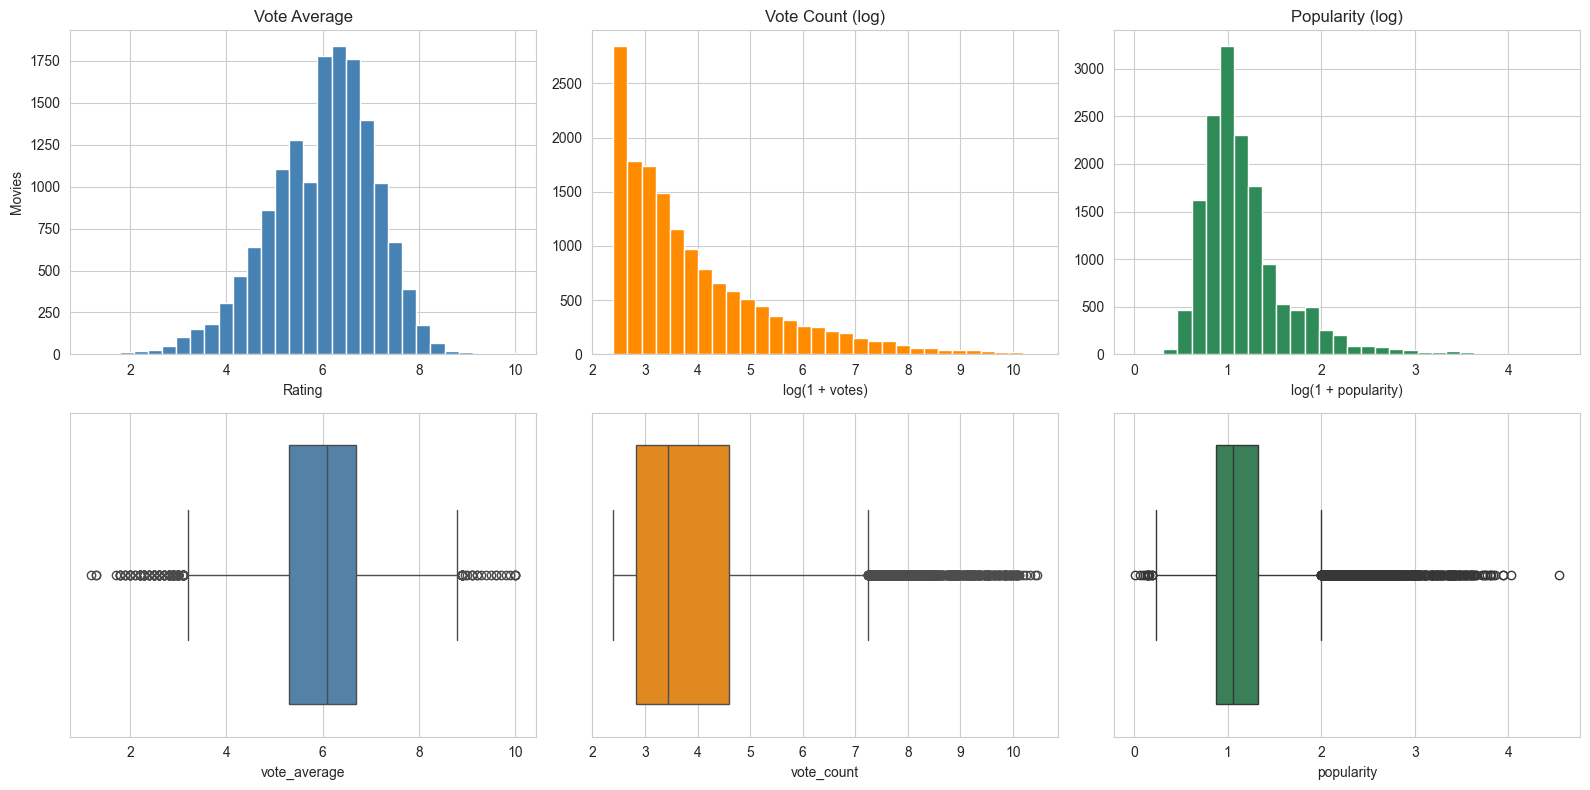

        vote_average  vote_count  popularity
mean            6.00      331.45        2.77
median          6.10       30.00        1.88
skew           -0.45       10.24        6.85

Rating stats, all vs vote_count>=20:
       all  votes>=20
mean  6.00       6.12
std   1.08       0.99


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ax[0,0].hist(df["vote_average"], bins=30, color="steelblue", edgecolor="white")
ax[0,0].set(title="Vote Average", xlabel="Rating", ylabel="Movies")
ax[0,1].hist(np.log1p(df["vote_count"]), bins=30, color="darkorange", edgecolor="white")
ax[0,1].set(title="Vote Count (log)", xlabel="log(1 + votes)")
ax[0,2].hist(np.log1p(df["popularity"]), bins=30, color="seagreen", edgecolor="white")
ax[0,2].set(title="Popularity (log)", xlabel="log(1 + popularity)")
sns.boxplot(x=df["vote_average"], ax=ax[1,0], color="steelblue")
sns.boxplot(x=np.log1p(df["vote_count"]), ax=ax[1,1], color="darkorange")
sns.boxplot(x=np.log1p(df["popularity"]), ax=ax[1,2], color="seagreen")
plt.tight_layout(); plt.show()

print(df[["vote_average", "vote_count", "popularity"]].agg(["mean", "median", "skew"]).round(2))
print("\nRating stats, all vs vote_count>=20:")
print(df["vote_average"].describe().round(2)[["mean", "std"]].to_frame("all").join(
      df[~df["low_votes"]]["vote_average"].describe().round(2)[["mean", "std"]].to_frame("votes>=20")))

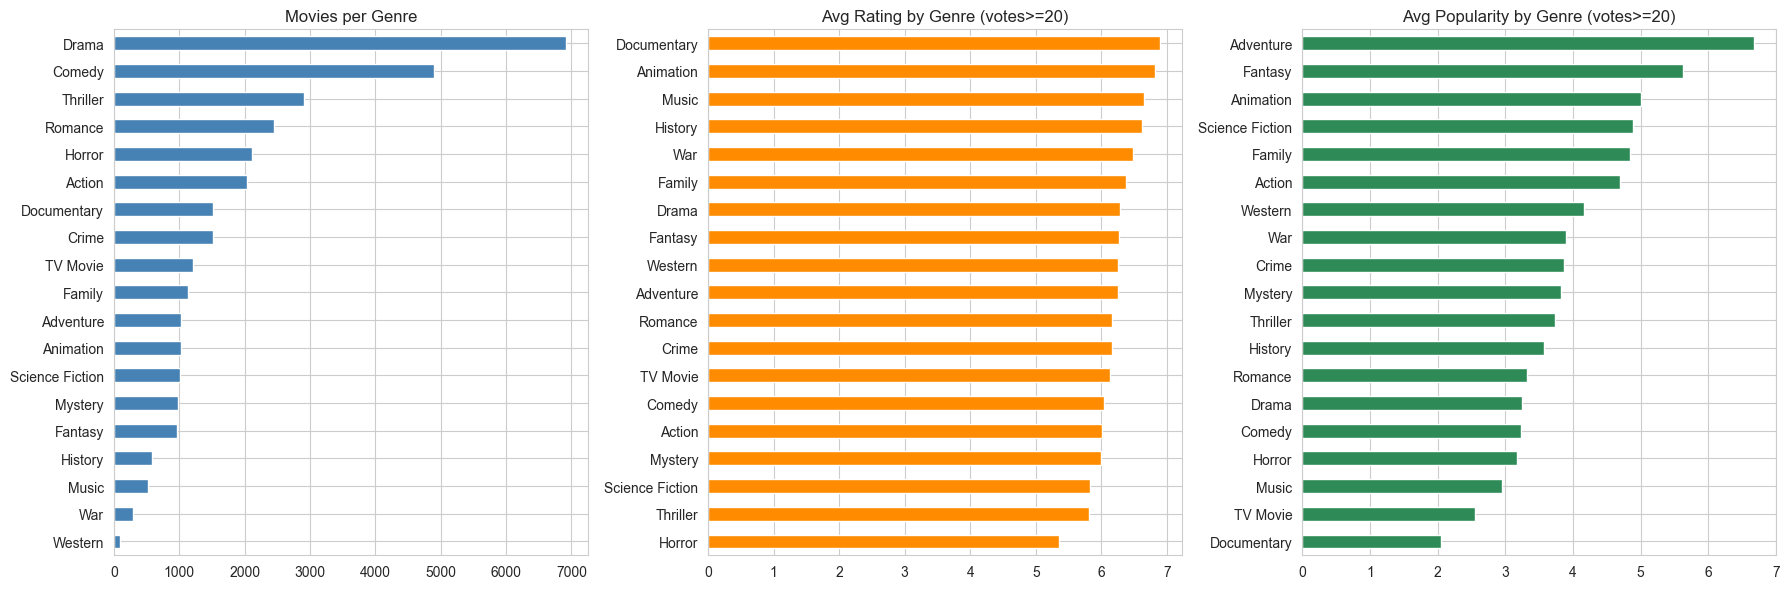

                 movies  avg_rating  avg_pop
genres                                      
Documentary        1515        6.89     2.05
Animation          1021        6.82     5.00
Music               518        6.65     2.95
History             587        6.62     3.57
War                 293        6.49     3.89
Family             1130        6.38     4.84
Drama              6910        6.29     3.24
Fantasy             963        6.27     5.62
Western              99        6.26     4.16
Adventure          1028        6.26     6.67
Romance            2450        6.17     3.32
Crime              1510        6.17     3.87
TV Movie           1216        6.13     2.56
Comedy             4898        6.04     3.23
Action             2033        6.01     4.70
Mystery             984        6.00     3.82
Science Fiction    1006        5.82     4.89
Thriller           2905        5.81     3.74
Horror             2117        5.36     3.18


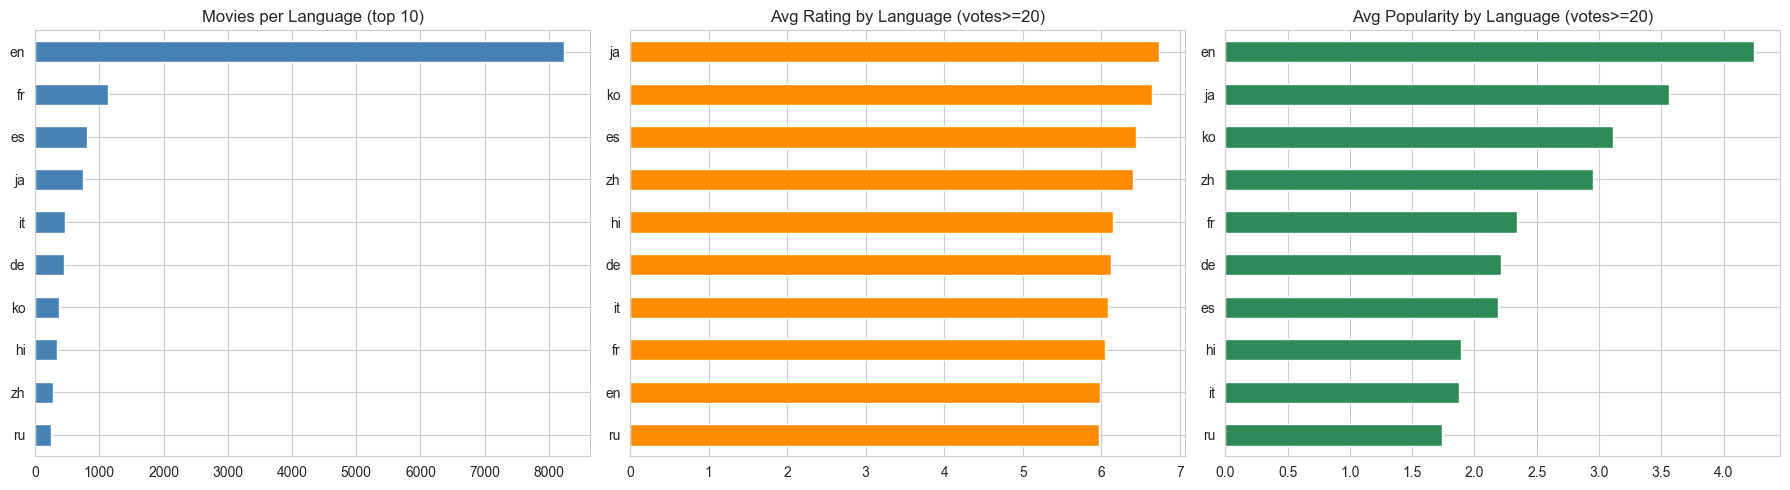

                   movies  avg_rating  avg_pop
original_language                             
ja                    751        6.73     3.56
ko                    377        6.65     3.11
es                    806        6.44     2.19
zh                    270        6.41     2.95
hi                    340        6.15     1.89
de                    443        6.12     2.21
it                    457        6.08     1.88
fr                   1138        6.05     2.34
en                   8229        5.99     4.24
ru                    248        5.97     1.74


In [12]:
g = df.explode("genres")
gr = g[~g["low_votes"]]

gs = pd.DataFrame({
    "movies": g["genres"].value_counts(),
    "avg_rating": gr.groupby("genres")["vote_average"].mean().round(2),
    "avg_pop": gr.groupby("genres")["popularity"].mean().round(2)
}).sort_values("avg_rating")

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
gs["movies"].sort_values().plot(kind="barh", ax=ax[0], color="steelblue", title="Movies per Genre")
gs["avg_rating"].plot(kind="barh", ax=ax[1], color="darkorange", title="Avg Rating by Genre (votes>=20)")
gs["avg_pop"].sort_values().plot(kind="barh", ax=ax[2], color="seagreen", title="Avg Popularity by Genre (votes>=20)")
for a in ax: a.set_ylabel("")
plt.tight_layout(); plt.show()
print(gs.sort_values("avg_rating", ascending=False))

top = df["original_language"].value_counts().head(10).index
lr = df[~df["low_votes"] & df["original_language"].isin(top)]
ls = pd.DataFrame({
    "movies": df[df["original_language"].isin(top)]["original_language"].value_counts(),
    "avg_rating": lr.groupby("original_language")["vote_average"].mean().round(2),
    "avg_pop": lr.groupby("original_language")["popularity"].mean().round(2)
}).sort_values("avg_rating")

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ls["movies"].sort_values().plot(kind="barh", ax=ax[0], color="steelblue", title="Movies per Language (top 10)")
ls["avg_rating"].plot(kind="barh", ax=ax[1], color="darkorange", title="Avg Rating by Language (votes>=20)")
ls["avg_pop"].sort_values().plot(kind="barh", ax=ax[2], color="seagreen", title="Avg Popularity by Language (votes>=20)")
for a in ax: a.set_ylabel("")
plt.tight_layout(); plt.show()
print(ls.sort_values("avg_rating", ascending=False))

## Genre

- **Most common:** Drama (6,910), Comedy (4,898) and Thriller (2,905). Western (99) and War (293) are rare, so treat their averages with caution.
- **Highest rated (votes ≥ 20):** Documentary (6.89), Animation (6.82), Music (6.65) and History (6.62).
- **Lowest rated:** Horror (5.36), Thriller (5.81) and Science Fiction (5.82). Horror is well below every other genre.
- **Rating and popularity don't always agree.** Documentary has the top rating but the lowest popularity (2.05). Adventure is the most popular (6.67) but only mid-table on rating (6.26). Animation is high on both (6.82 rating, 5.00 popularity), the strongest combination.

## Language

- **English dominates:** 8,229 movies, about 53% of the data. French (1,138) and Spanish (806) follow.
- **Highest rated:** Japanese (6.73), Korean (6.65), Spanish (6.44) and Chinese (6.41).
- **English is second-lowest on rating (5.99) but first on popularity (4.24).** So popularity reflects reach, not quality.
- **Caveat:** Non-English films that pass 20 votes are probably a self-selected, better-received group because they need to attract an international audience. Say this in your notes rather than claiming these languages are simply better.

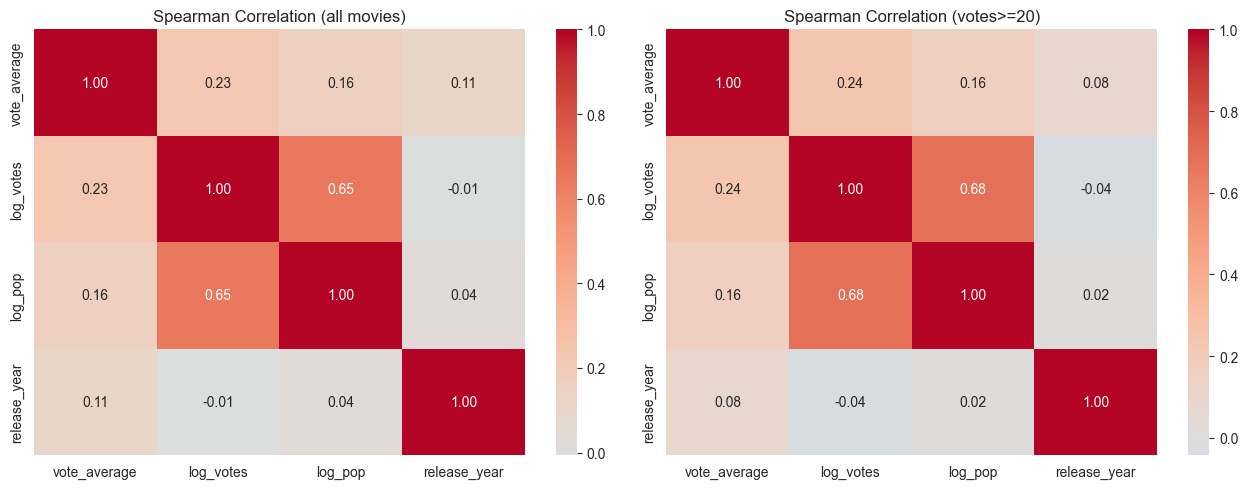

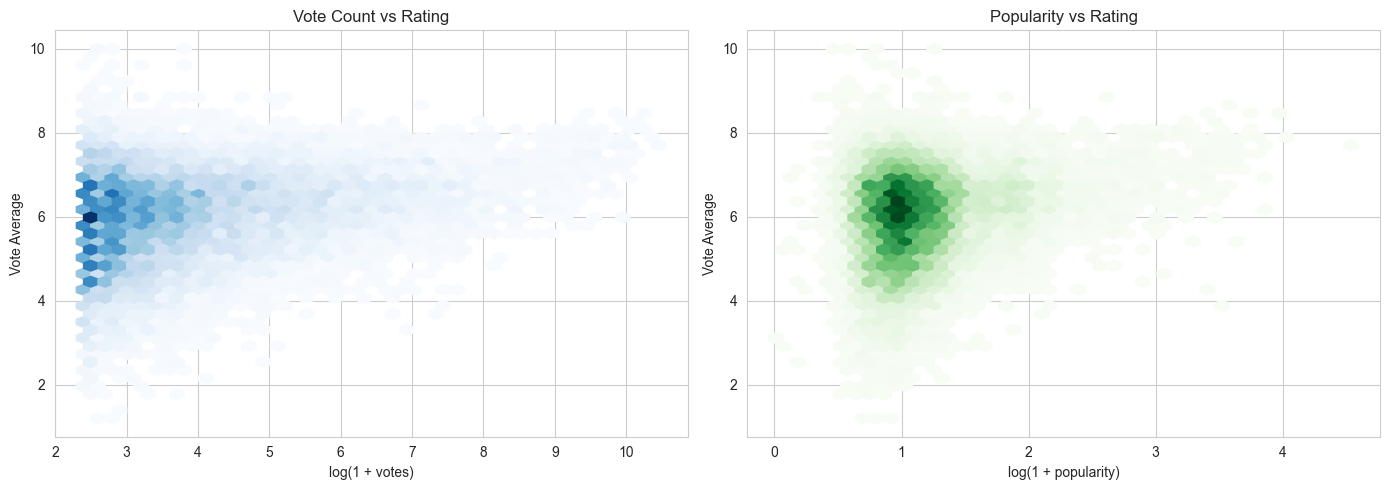

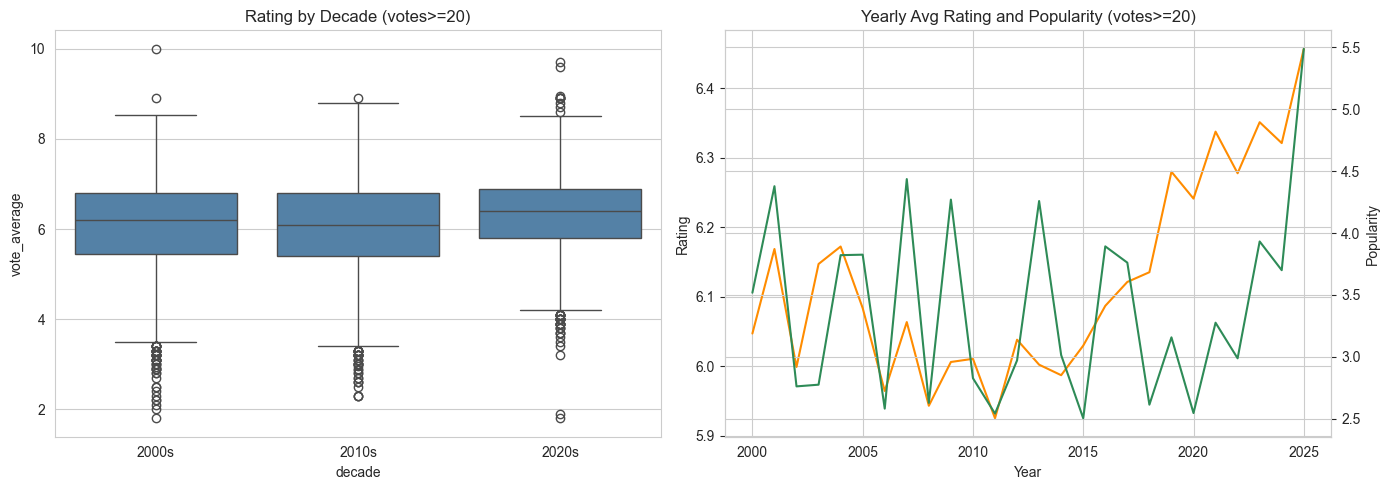

              vote_average  log_votes  log_pop  release_year
vote_average          1.00       0.23     0.16          0.11
log_votes             0.23       1.00     0.65         -0.01
log_pop               0.16       0.65     1.00          0.04
release_year          0.11      -0.01     0.04          1.00
              vote_average  log_votes  log_pop  release_year
vote_average          1.00       0.24     0.16          0.08
log_votes             0.24       1.00     0.68         -0.04
log_pop               0.16       0.68     1.00          0.02
release_year          0.08      -0.04     0.02          1.00
        count  mean
decade             
2000s    3827  6.06
2010s    3910  6.06
2020s    2341  6.33


In [13]:
d = df.copy()
d["log_pop"] = np.log1p(d["popularity"])
d["log_votes"] = np.log1p(d["vote_count"])
d["decade"] = (d["release_year"] // 10 * 10).astype(str) + "s"
rel = d[~d["low_votes"]]
cols = ["vote_average", "log_votes", "log_pop", "release_year"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(d[cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0])
ax[0].set_title("Spearman Correlation (all movies)")
sns.heatmap(rel[cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[1])
ax[1].set_title("Spearman Correlation (votes>=20)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hexbin(d["log_votes"], d["vote_average"], gridsize=40, cmap="Blues", mincnt=1)
ax[0].set(title="Vote Count vs Rating", xlabel="log(1 + votes)", ylabel="Vote Average")
ax[1].hexbin(d["log_pop"], d["vote_average"], gridsize=40, cmap="Greens", mincnt=1)
ax[1].set(title="Popularity vs Rating", xlabel="log(1 + popularity)", ylabel="Vote Average")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=rel, x="decade", y="vote_average", ax=ax[0], color="steelblue")
ax[0].set_title("Rating by Decade (votes>=20)")
yr = rel.groupby("release_year")[["vote_average", "popularity"]].mean()
ax[1].plot(yr.index, yr["vote_average"], color="darkorange", label="Avg rating")
ax2 = ax[1].twinx(); ax2.plot(yr.index, yr["popularity"], color="seagreen", label="Avg popularity")
ax[1].set(title="Yearly Avg Rating and Popularity (votes>=20)", xlabel="Year", ylabel="Rating")
ax2.set_ylabel("Popularity")
plt.tight_layout(); plt.show()

print(d[cols].corr(method="spearman").round(2))
print(rel[cols].corr(method="spearman").round(2))
print(rel.groupby("decade")["vote_average"].agg(["count", "mean"]).round(2))

In [14]:
from sklearn.preprocessing import MultiLabelBinarizer

m = df[df["vote_count"] >= 20].copy()
m["high_rated"] = (m["vote_average"] >= 6.5).astype(int)
print(len(m), "movies | high_rated share:", m["high_rated"].mean().round(3))

mlb = MultiLabelBinarizer()
gx = pd.DataFrame(mlb.fit_transform(m["genres"]), index=m.index,
                  columns=["g_" + c for c in mlb.classes_])

top = m["original_language"].value_counts().head(10).index
m["lang"] = m["original_language"].where(m["original_language"].isin(top), "other")
lx = pd.get_dummies(m["lang"], prefix="l", dtype=int)

m["month"] = m["release_date"].dt.month
m["ov_words"] = m["overview"].str.split().str.len()
m["n_genres"] = m["genres"].str.len()
m["log_pop"] = np.log1p(m["popularity"])
m["log_votes"] = np.log1p(m["vote_count"])

base = ["release_year", "month", "ov_words", "n_genres"]
X_a = pd.concat([m[base], gx, lx], axis=1)
X_b = pd.concat([X_a, m[["log_pop", "log_votes"]]], axis=1)
y = m["high_rated"]

print("X_a:", X_a.shape, "| X_b:", X_b.shape, "| NaNs:", X_b.isna().sum().sum())
print(X_a.columns.tolist())
m.to_csv("data/processed/tmdb_model.csv", index=False)

10078 movies | high_rated share: 0.39
X_a: (10078, 34) | X_b: (10078, 36) | NaNs: 0
['release_year', 'month', 'ov_words', 'n_genres', 'g_Action', 'g_Adventure', 'g_Animation', 'g_Comedy', 'g_Crime', 'g_Documentary', 'g_Drama', 'g_Family', 'g_Fantasy', 'g_History', 'g_Horror', 'g_Music', 'g_Mystery', 'g_Romance', 'g_Science Fiction', 'g_TV Movie', 'g_Thriller', 'g_War', 'g_Western', 'l_de', 'l_en', 'l_es', 'l_fr', 'l_hi', 'l_it', 'l_ja', 'l_ko', 'l_other', 'l_ru', 'l_zh']


In [15]:
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# clean text
m["clean"] = m["overview"].str.lower().apply(lambda t: re.sub(r"[^a-z\s]", " ", t))

# split once, reuse everywhere
tr, te = train_test_split(m.index, test_size=0.2, stratify=y, random_state=42)

# TF-IDF fitted on train only
tf = TfidfVectorizer(stop_words="english", max_features=1000, ngram_range=(1, 2), min_df=5)
T_tr = tf.fit_transform(m.loc[tr, "clean"])
T_te = tf.transform(m.loc[te, "clean"])
print("train:", T_tr.shape, "| test:", T_te.shape)
print("train positives:", y.loc[tr].mean().round(3), "| test positives:", y.loc[te].mean().round(3))

# important terms
terms = np.array(tf.get_feature_names_out())
avg = np.asarray(T_tr.mean(axis=0)).ravel()
print("\nTop terms overall:", list(terms[avg.argsort()[::-1][:15]]))

hi = (y.loc[tr] == 1).values
diff = np.asarray(T_tr[hi].mean(axis=0)).ravel() - np.asarray(T_tr[~hi].mean(axis=0)).ravel()
print("\nMore common in high-rated:", list(terms[diff.argsort()[::-1][:15]]))
print("\nMore common in low-rated:", list(terms[diff.argsort()[:15]]))

train: (8062, 1000) | test: (2016, 1000)
train positives: 0.39 | test positives: 0.39

Top terms overall: ['life', 'young', 'family', 'man', 'new', 'world', 'love', 'old', 'story', 'woman', 'friends', 'years', 'year', 'time', 'father']

More common in high-rated: ['story', 'documentary', 'war', 'life', 'world', 'journey', 'boy', 'film', 'music', 'years', 'history', 'village', 'footage', 'interviews', 'time']

More common in low-rated: ['group', 'woman', 'night', 'couple', 'town', 'college', 'killer', 'soon', 'decide', 'friends', 'boyfriend', 'evil', 'christmas', 'wrong', 'turns']


In [16]:
!pip install xgboost -q
from scipy.sparse import hstack, csr_matrix
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

ytr, yte = y.loc[tr], y.loc[te]
sets = {}
for n, X in [("A", X_a), ("B", X_b)]:
    a = csr_matrix(X.loc[tr].values.astype(float))
    b = csr_matrix(X.loc[te].values.astype(float))
    sets[n] = (a, b)
    sets[n + "+text"] = (hstack([a, T_tr]).tocsr(), hstack([b, T_te]).tocsr())

models = {
    "Dummy": DummyClassifier(strategy="prior"),
    "LogReg": LogisticRegression(max_iter=2000),
    "RandForest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                             random_state=42, eval_metric="logloss")}

res = []
for s, (a, b) in sets.items():
    sc = StandardScaler(with_mean=False).fit(a)
    for n, mdl in models.items():
        x1, x2 = (sc.transform(a), sc.transform(b)) if n == "LogReg" else (a, b)
        mdl.fit(x1, ytr)
        p = mdl.predict(x2)
        pr = mdl.predict_proba(x2)[:, 1]
        res.append({"features": s, "model": n, "acc": accuracy_score(yte, p),
                    "f1": f1_score(yte, p), "auc": roc_auc_score(yte, pr)})

print(pd.DataFrame(res).round(3).to_string(index=False))


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


features      model   acc    f1   auc
       A      Dummy 0.610 0.000 0.500
       A     LogReg 0.730 0.597 0.768
       A RandForest 0.707 0.589 0.750
       A    XGBoost 0.721 0.599 0.769
  A+text      Dummy 0.610 0.000 0.500
  A+text     LogReg 0.680 0.570 0.715
  A+text RandForest 0.727 0.586 0.768
  A+text    XGBoost 0.726 0.597 0.768
       B      Dummy 0.610 0.000 0.500
       B     LogReg 0.763 0.670 0.813
       B RandForest 0.759 0.660 0.829
       B    XGBoost 0.758 0.663 0.827
  B+text      Dummy 0.610 0.000 0.500
  B+text     LogReg 0.708 0.607 0.760
  B+text RandForest 0.751 0.624 0.820
  B+text    XGBoost 0.755 0.647 0.822


In [17]:
import joblib
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold

cv = StratifiedKFold(5, shuffle=True, random_state=42)
grids = {
    "XGBoost": (XGBClassifier(random_state=42, eval_metric="logloss"),
                {"max_depth": [3, 5, 7], "n_estimators": [200, 400], "learning_rate": [0.05, 0.1]}),
    "RandForest": (RandomForestClassifier(n_estimators=300, random_state=42),
                   {"max_depth": [None, 10, 20], "min_samples_leaf": [1, 3, 5]})}

os.makedirs("models", exist_ok=True)
out = []
for fs, X in [("B", X_b), ("A", X_a)]:
    xtr, xte = X.loc[tr], X.loc[te]
    for n, (mdl, g) in grids.items():
        cv_base = cross_val_score(mdl, xtr, ytr, cv=cv, scoring="roc_auc").mean()
        gs = GridSearchCV(mdl, g, cv=cv, scoring="roc_auc", n_jobs=-1).fit(xtr, ytr)
        b = gs.best_estimator_
        p, pr = b.predict(xte), b.predict_proba(xte)[:, 1]
        out.append({"features": fs, "model": n, "cv_untuned": cv_base, "cv_tuned": gs.best_score_,
                    "test_acc": accuracy_score(yte, p), "test_f1": f1_score(yte, p),
                    "test_auc": roc_auc_score(yte, pr)})
        print(fs, n, gs.best_params_)
        joblib.dump(b, f"models/{n}_{fs}.pkl")

print(pd.DataFrame(out).round(3).to_string(index=False))

B XGBoost {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400}
B RandForest {'max_depth': 20, 'min_samples_leaf': 3}
A XGBoost {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
A RandForest {'max_depth': 20, 'min_samples_leaf': 5}
features      model  cv_untuned  cv_tuned  test_acc  test_f1  test_auc
       B    XGBoost       0.798     0.815     0.771    0.677     0.834
       B RandForest       0.816     0.819     0.758    0.650     0.836
       A    XGBoost       0.728     0.757     0.734    0.607     0.780
       A RandForest       0.739     0.761     0.736    0.608     0.785



=== RandForest, set B (with popularity/votes) ===
              precision    recall  f1-score   support

    not high      0.763     0.876     0.816      1230
        high      0.747     0.575     0.650       786

    accuracy                          0.758      2016
   macro avg      0.755     0.725     0.733      2016
weighted avg      0.757     0.758     0.751      2016

AUC: 0.836

=== RandForest, set A (content only) ===
              precision    recall  f1-score   support

    not high      0.742     0.869     0.800      1230
        high      0.720     0.527     0.608       786

    accuracy                          0.736      2016
   macro avg      0.731     0.698     0.704      2016
weighted avg      0.733     0.736     0.726      2016

AUC: 0.785


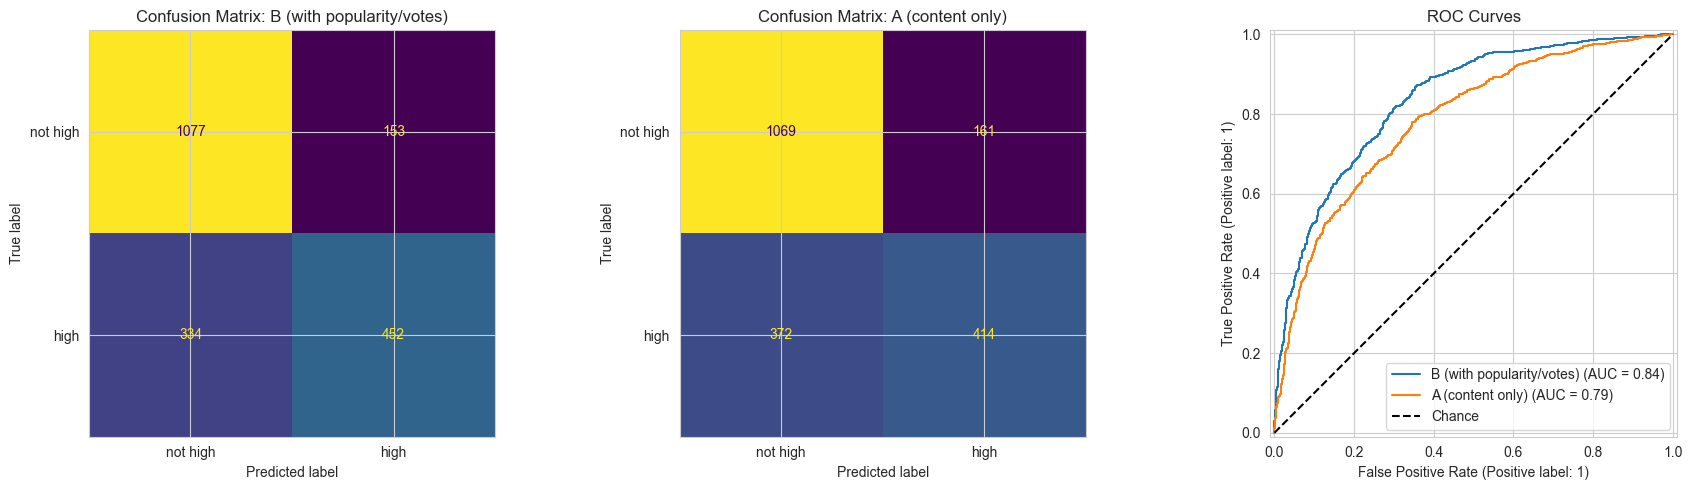

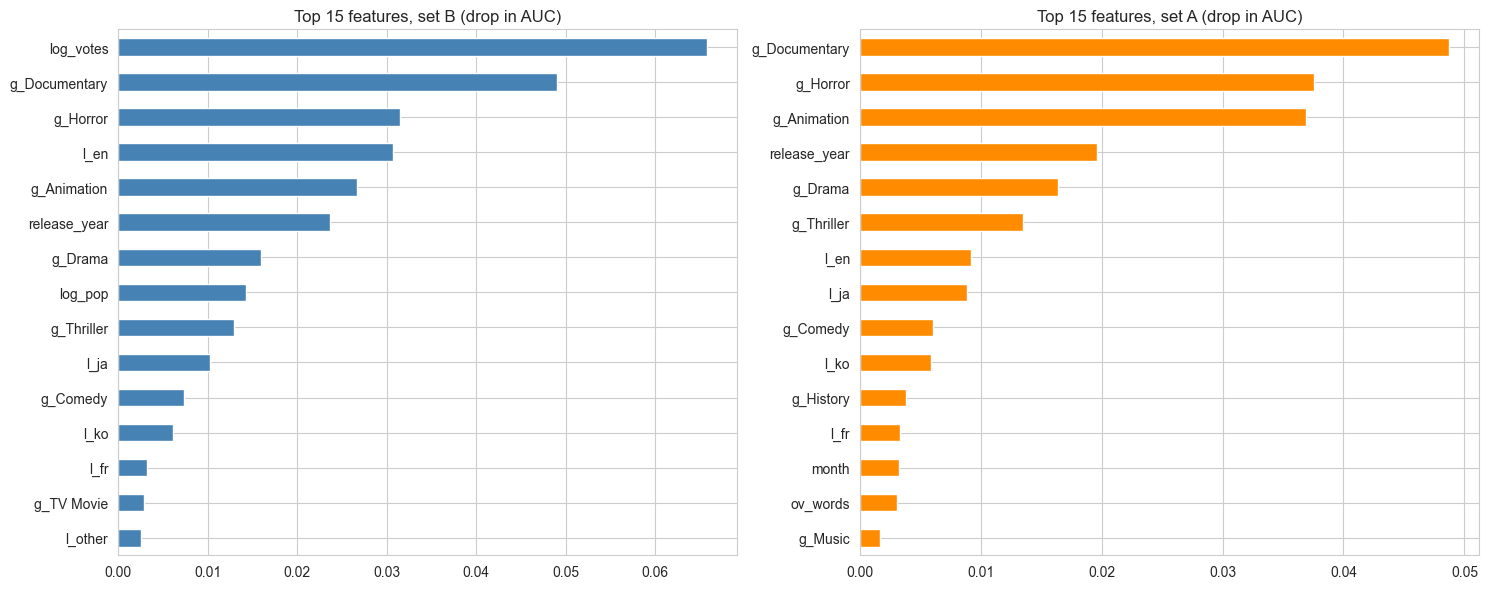

log_votes        0.0658
g_Documentary    0.0490
g_Horror         0.0315
l_en             0.0307
g_Animation      0.0267
release_year     0.0237
g_Drama          0.0160
log_pop          0.0143
g_Thriller       0.0130
l_ja             0.0102
g_Comedy         0.0074
l_ko             0.0061
l_fr             0.0033
g_TV Movie       0.0030
l_other          0.0025
g_Documentary    0.0487
g_Horror         0.0376
g_Animation      0.0369
release_year     0.0196
g_Drama          0.0164
g_Thriller       0.0135
l_en             0.0092
l_ja             0.0088
g_Comedy         0.0060
l_ko             0.0059
g_History        0.0038
l_fr             0.0033
month            0.0032
ov_words         0.0031
g_Music          0.0016

Robustness (>=50 votes): 5717 movies | positives: 0.449 | AUC: 0.841


In [18]:
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, RocCurveDisplay)
from sklearn.inspection import permutation_importance

fin = {"B (with popularity/votes)": (joblib.load("models/RandForest_B.pkl"), X_b),
       "A (content only)": (joblib.load("models/RandForest_A.pkl"), X_a)}

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for i, (n, (mdl, X)) in enumerate(fin.items()):
    p, pr = mdl.predict(X.loc[te]), mdl.predict_proba(X.loc[te])[:, 1]
    print(f"\n=== RandForest, set {n} ===")
    print(classification_report(yte, p, target_names=["not high", "high"], digits=3))
    print("AUC:", round(roc_auc_score(yte, pr), 3))
    ConfusionMatrixDisplay(confusion_matrix(yte, p), display_labels=["not high", "high"]).plot(ax=ax[i], colorbar=False)
    ax[i].set_title(f"Confusion Matrix: {n}")
    RocCurveDisplay.from_predictions(yte, pr, ax=ax[2], name=n)
ax[2].plot([0, 1], [0, 1], "k--", label="Chance"); ax[2].legend(); ax[2].set_title("ROC Curves")
plt.tight_layout(); plt.show()

mdl, X = fin["B (with popularity/votes)"]
pi = permutation_importance(mdl, X.loc[te], yte, scoring="roc_auc", n_repeats=5, random_state=42, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values().tail(15)
mdl_a, X_ = fin["A (content only)"]
pa = permutation_importance(mdl_a, X_.loc[te], yte, scoring="roc_auc", n_repeats=5, random_state=42, n_jobs=-1)
imp_a = pd.Series(pa.importances_mean, index=X_.columns).sort_values().tail(15)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
imp.plot(kind="barh", ax=ax[0], color="steelblue", title="Top 15 features, set B (drop in AUC)")
imp_a.plot(kind="barh", ax=ax[1], color="darkorange", title="Top 15 features, set A (drop in AUC)")
plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(4).to_string())
print(imp_a.sort_values(ascending=False).round(4).to_string())

# robustness: same pipeline at >= 50 votes
r = df[df["vote_count"] >= 50].copy()
r["y"] = (r["vote_average"] >= 6.5).astype(int)
r["log_pop"], r["log_votes"] = np.log1p(r["popularity"]), np.log1p(r["vote_count"])
r["month"], r["ov_words"], r["n_genres"] = r["release_date"].dt.month, r["overview"].str.split().str.len(), r["genres"].str.len()
gr_ = pd.DataFrame(MultiLabelBinarizer().fit_transform(r["genres"]), index=r.index)
r["lang"] = r["original_language"].where(r["original_language"].isin(top), "other")
Xr = pd.concat([r[["release_year", "month", "ov_words", "n_genres", "log_pop", "log_votes"]], gr_, pd.get_dummies(r["lang"], dtype=int)], axis=1)
Xr.columns = Xr.columns.astype(str)
a, b, c, d = train_test_split(Xr, r["y"], test_size=0.2, stratify=r["y"], random_state=42)
rf = RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=3, n_jobs=-1, random_state=42).fit(a, c)
print("\nRobustness (>=50 votes):", len(r), "movies | positives:", round(r["y"].mean(), 3),
      "| AUC:", round(roc_auc_score(d, rf.predict_proba(b)[:, 1]), 3))

## Insights for Issues 16 and 17

### Evaluation (Random Forest, test set of 2,016 movies)

| Feature set | Accuracy | High-rated Precision | High-rated Recall | F1 | AUC |
|---|---:|---:|---:|---:|---:|
| B (with popularity and votes) | 0.758 | 0.747 | 0.575 | 0.650 | 0.836 |
| A (content only) | 0.736 | 0.720 | 0.527 | 0.608 | 0.785 |
| Dummy baseline | 0.610 | 0 | 0 | 0 | 0.500 |

- Both models clearly outperform the baseline, and the ROC curve for B remains above A across the range.
- **Confusion matrix (B):** 1,077 correct "not high", 452 correct "high", 153 false alarms and 334 misses.
- The model is cautious: when it predicts "high", it is correct 75% of the time, but it identifies only 57.5% of truly high-rated movies.
- Lowering the decision threshold would trade precision for recall, which could help reduce the 43% of high-rated movies that were missed.
- **Set B vs A:** Adding audience engagement features improves AUC by about 0.05. Set A achieves an AUC of 0.785 using content features alone, showing that ratings are partly predictable from movie characteristics.

### Feature Importance

Feature importance is measured by the drop in AUC when a feature is shuffled.

#### Set B

- `log_votes`: 0.066
- `g_Documentary`: 0.049
- `g_Horror`: 0.032
- `l_en`: 0.031
- `g_Animation`: 0.027
- `release_year`: 0.024

#### Set A

- `g_Documentary`: 0.049
- `g_Horror`: 0.038
- `g_Animation`: 0.037
- `release_year`: 0.020
- `g_Drama`: 0.016

- **Genre is the strongest content signal.** This matches the EDA, where Documentary and Animation have high ratings while Horror has the lowest.
- **Vote count is the strongest single feature.** Movies with more votes tend to have higher ratings (Spearman correlation = 0.24), consistent with the funnel pattern in the hexbin plot.
- Language and release year have smaller effects but still contribute to prediction. This is consistent with the lower average rating for English-language movies and the increase in ratings after 2016.
- **Text features added little predictive value** (Issues 13/14), so they are used mainly for interpretation in Issue 19.

### Robustness

- Using a stricter 50+ vote threshold gives an AUC of 0.841 across 5,717 movies, compared with 0.836 using the 20-vote threshold.
- This suggests that the model's conclusions are reasonably stable and do not depend strongly on the 20-vote cutoff.
- The proportion of high-rated movies is higher in the 50+ vote group because heavily voted movies tend to have higher ratings.

### Limitations

- Feature importance shows what the model uses for prediction, not the direction or cause of the relationship. Direction should be interpreted using the EDA results.
- `log_votes` and `log_pop` are correlated (0.65–0.68), so their importance may be distributed between them.
- Set B uses post-release audience data, so it explains ratings but is not suitable for pre-release prediction. Set A represents the pre-release version.
- Ratings are based on a sample of about 600 movies per year, and movies with fewer than 20 votes are excluded.